## 1. Imports

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
from tensorflow.keras import layers
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.1
GPU available: []


## 2. Configuration
> ⚙️ **Edit the paths below** to point to your saved model files and test image.

In [19]:
# ── Paths ────────────────────────────────────────────────────────────────────
VIT_MODEL_PATH        = r'D:\Leaf dataset 2\outputs\ViT\ViT_best.keras'
MOBILENET_MODEL_PATH  = r'D:\Leaf dataset 2\outputs\MobileNetV1\MobileNetV1_best.keras'
TEST_IMAGE_PATH       = r"D:\Leaf dataset 2\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\test\CornCommonRust1.JPG"   # <-- change this

# ── Model settings (must match training) ─────────────────────────────────────
IMG_SIZE = 224
TOP_K    = 5   # how many top predictions to display

# ── 38 Class names (New Plant Diseases Dataset) ───────────────────────────────
CLASS_NAMES = [
    'Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy',
    'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_',
    'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy',
    'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy',
    'Orange___Haunglongbing_(Citrus_greening)',
    'Peach___Bacterial_spot', 'Peach___healthy',
    'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy',
    'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy',
    'Raspberry___healthy',
    'Soybean___healthy',
    'Squash___Powdery_mildew',
    'Strawberry___Leaf_scorch', 'Strawberry___healthy',
    'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight',
    'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy',
]

print(f'✅ Config loaded — {len(CLASS_NAMES)} classes')

✅ Config loaded — 38 classes


## 3. Custom Layer Definitions (required for ViT)
ح

In [20]:
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim  = embed_dim
        self.projection = layers.Conv2D(
            filters=embed_dim, kernel_size=patch_size,
            strides=patch_size, padding='valid',
        )
        self.flatten = layers.Reshape((-1, embed_dim))

    def call(self, images):
        x = self.projection(images)
        return self.flatten(x)

    def get_config(self):
        config = super().get_config()
        config.update({'patch_size': self.patch_size, 'embed_dim': self.embed_dim})
        return config


class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.embed_dim   = embed_dim

    def build(self, input_shape):
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim), initializer='zeros',
            trainable=True, name='cls_token'
        )
        self.pos_embed = self.add_weight(
            shape=(1, self.num_patches + 1, self.embed_dim),
            initializer='random_normal', trainable=True, name='pos_embed'
        )

    def call(self, x):
        batch_size = tf.shape(x)[0]
        cls = tf.broadcast_to(self.cls_token, (batch_size, 1, self.embed_dim))
        x = tf.concat([cls, x], axis=1)
        return x + self.pos_embed

    def get_config(self):
        config = super().get_config()
        config.update({'num_patches': self.num_patches, 'embed_dim': self.embed_dim})
        return config


class ExtractCLS(layers.Layer):
    def call(self, x):
        return x[:, 0, :]

    def get_config(self):
        return super().get_config()


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim    = embed_dim
        self.num_heads    = num_heads
        self.mlp_dim      = mlp_dim
        self.dropout_rate = dropout_rate
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn  = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=dropout_rate
        )
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.fc1   = layers.Dense(mlp_dim, activation='gelu')
        self.fc2   = layers.Dense(embed_dim)
        self.drop  = layers.Dropout(dropout_rate)

    def call(self, x, training=False):
        dtype = x.dtype
        attn_out = self.attn(self.norm1(x), self.norm1(x), training=training)
        attn_out = tf.cast(attn_out, dtype)
        x = x + tf.cast(self.drop(attn_out, training=training), dtype)
        mlp_out = self.fc2(self.drop(self.fc1(self.norm2(x)), training=training))
        mlp_out = tf.cast(mlp_out, dtype)
        return x + tf.cast(self.drop(mlp_out, training=training), dtype)

    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim, 'num_heads': self.num_heads,
            'mlp_dim': self.mlp_dim, 'dropout_rate': self.dropout_rate,
        })
        return config


print('✅ Custom ViT layers registered')

✅ Custom ViT layers registered


## 4. Load Models

In [21]:
# Pass all custom ViT layers explicitly — this works regardless of TF version
CUSTOM_OBJECTS = {
    'PatchEmbedding':      PatchEmbedding,
    'PositionalEmbedding': PositionalEmbedding,
    'ExtractCLS':          ExtractCLS,
    'TransformerBlock':    TransformerBlock,
}

print('Loading ViT model...')
vit_model = tf.keras.models.load_model(VIT_MODEL_PATH, custom_objects=CUSTOM_OBJECTS)
print(f'  ✅ ViT loaded   — input shape: {vit_model.input_shape}')

print('Loading MobileNetV1 model...')
mobilenet_model = tf.keras.models.load_model(MOBILENET_MODEL_PATH)
print(f'  ✅ MobileNetV1 loaded — input shape: {mobilenet_model.input_shape}')

Loading ViT model...
  ✅ ViT loaded   — input shape: (None, 224, 224, 3)
Loading MobileNetV1 model...
  ✅ MobileNetV1 loaded — input shape: (None, 224, 224, 3)


## 5. Image Preprocessing

In [22]:
def load_and_preprocess(image_path, img_size=224):
    """
    Load an image from disk, resize to (img_size x img_size),
    normalize to [0, 1], and add a batch dimension.
    Returns: original PIL image, preprocessed tensor (1, H, W, 3)
    """
    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize((img_size, img_size))
    arr = np.array(img_resized, dtype=np.float32) / 255.0
    tensor = np.expand_dims(arr, axis=0)  # (1, 224, 224, 3)
    return img, tensor


original_img, img_tensor = load_and_preprocess(TEST_IMAGE_PATH, IMG_SIZE)
print(f'✅ Image loaded — original size: {original_img.size}, tensor shape: {img_tensor.shape}')

✅ Image loaded — original size: (256, 256), tensor shape: (1, 224, 224, 3)


## 6. Run Inference

In [23]:
def predict_topk(model, img_tensor, class_names, k=5):
    """Run inference and return top-k (class_name, confidence) pairs."""
    probs = model.predict(img_tensor, verbose=0)[0]       # shape: (38,)
    top_indices = np.argsort(probs)[::-1][:k]
    return [(class_names[i], float(probs[i])) for i in top_indices]


print('Running ViT inference...')
vit_preds = predict_topk(vit_model, img_tensor, CLASS_NAMES, TOP_K)
print(f'  ViT top prediction: {vit_preds[0][0]}  ({vit_preds[0][1]*100:.2f}%)')

print('Running MobileNetV1 inference...')
mob_preds = predict_topk(mobilenet_model, img_tensor, CLASS_NAMES, TOP_K)
print(f'  MobileNetV1 top prediction: {mob_preds[0][0]}  ({mob_preds[0][1]*100:.2f}%)')

Running ViT inference...
  ViT top prediction: Corn_(maize)___Common_rust_  (100.00%)
Running MobileNetV1 inference...
  MobileNetV1 top prediction: Corn_(maize)___Common_rust_  (100.00%)


## 7. Visualization — Side-by-Side Comparison

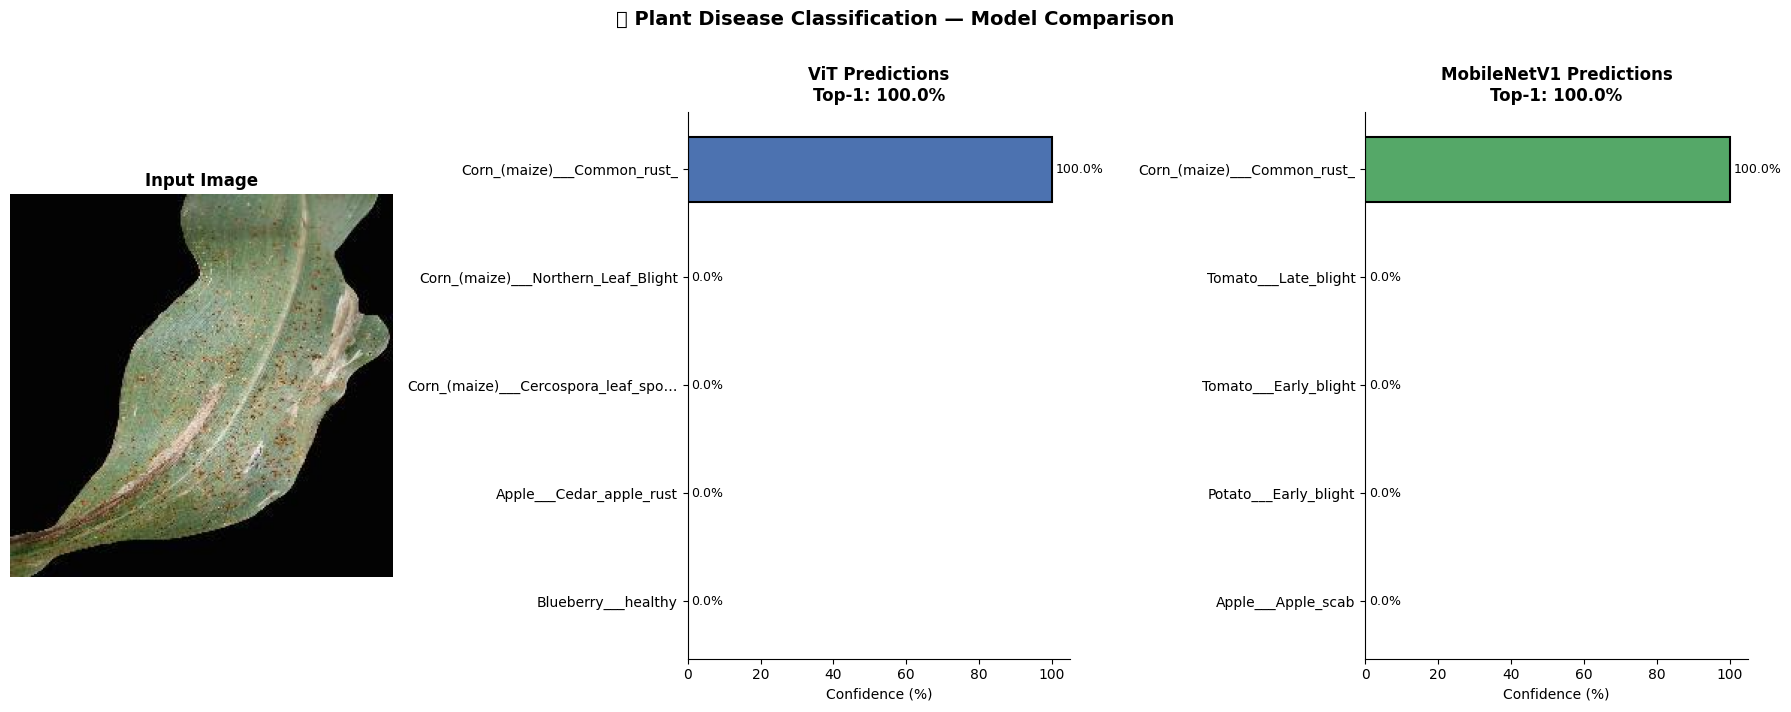


📊 Plot saved as prediction_comparison.png


In [24]:
def shorten(name, max_len=35):
    """Shorten long class names for display."""
    return name if len(name) <= max_len else name[:max_len - 1] + '…'


def plot_bar(ax, preds, title, color):
    labels = [shorten(p[0]) for p in reversed(preds)]
    scores = [p[1] * 100 for p in reversed(preds)]
    bars   = ax.barh(labels, scores, color=color, edgecolor='white', height=0.6)
    ax.set_xlim(0, 105)
    ax.set_xlabel('Confidence (%)', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.spines[['top', 'right']].set_visible(False)
    # Annotate bars
    for bar, score in zip(bars, scores):
        ax.text(score + 1, bar.get_y() + bar.get_height() / 2,
                f'{score:.1f}%', va='center', fontsize=9)
    # Highlight top prediction
    bars[-1].set_edgecolor('black')
    bars[-1].set_linewidth(1.5)


fig = plt.figure(figsize=(18, 7))
fig.suptitle('🌿 Plant Disease Classification — Model Comparison', fontsize=14, fontweight='bold', y=1.01)

# Input image
ax_img = fig.add_subplot(1, 3, 1)
ax_img.imshow(original_img)
ax_img.set_title('Input Image', fontsize=12, fontweight='bold')
ax_img.axis('off')

# ViT predictions
ax_vit = fig.add_subplot(1, 3, 2)
plot_bar(ax_vit, vit_preds, f'ViT Predictions\nTop-1: {vit_preds[0][1]*100:.1f}%', '#4C72B0')

# MobileNetV1 predictions
ax_mob = fig.add_subplot(1, 3, 3)
plot_bar(ax_mob, mob_preds, f'MobileNetV1 Predictions\nTop-1: {mob_preds[0][1]*100:.1f}%', '#55A868')

plt.tight_layout()
plt.savefig('prediction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📊 Plot saved as prediction_comparison.png')